In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [16]:
data = load_breast_cancer()
X = data.data
y = data.target

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# (a) Scale the features using StandardScaler 

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# (b) Train two SVM models — Linear and RBF

In [27]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Linear SVM
svm_linear = SVC(kernel="linear")
svm_linear.fit(X_train_scaled, y_train)

y_pred_linear = svm_linear.predict(X_test_scaled)

linear_accuracy = accuracy_score(y_test, y_pred_linear)

print("Linear SVM Accuracy:", linear_accuracy)

Linear SVM Accuracy: 0.9736842105263158


In [28]:
# RBF SVM
svm_rbf = SVC(kernel="rbf")
svm_rbf.fit(X_train_scaled, y_train)

y_pred_rbf = svm_rbf.predict(X_test_scaled)

rbf_accuracy = accuracy_score(y_test, y_pred_rbf)

print("RBF SVM Accuracy:", rbf_accuracy)

RBF SVM Accuracy: 0.9824561403508771


# (c) Confusion Matrix + Accuracy, Precision, Recall, F1-score 

In [21]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

cm_linear = confusion_matrix(y_test, y_pred_linear)

print("Confusion Matrix:")
print(cm_linear)

print("\nAccuracy :", accuracy_score(y_test, y_pred_linear))
print("Precision:", precision_score(y_test, y_pred_linear))
print("Recall   :", recall_score(y_test, y_pred_linear))
print("F1-score :", f1_score(y_test, y_pred_linear))

Confusion Matrix:
[[41  1]
 [ 2 70]]

Accuracy : 0.9736842105263158
Precision: 0.9859154929577465
Recall   : 0.9722222222222222
F1-score : 0.9790209790209791


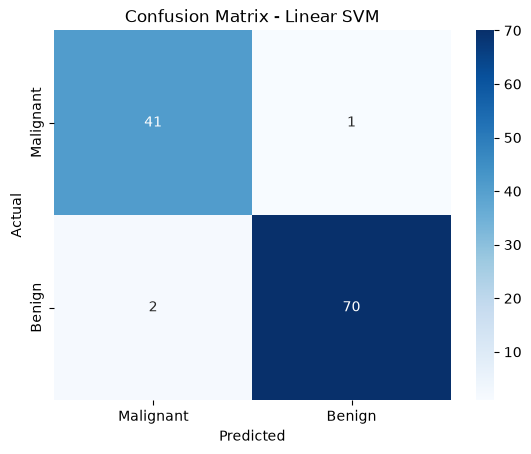

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    cm_linear,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Malignant", "Benign"],
    yticklabels=["Malignant", "Benign"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Linear SVM")
plt.show()

In [29]:
cm_rbf = confusion_matrix(y_test, y_pred_rbf)

print("Confusion Matrix:")
print(cm_rbf)

print("\nAccuracy :", accuracy_score(y_test, y_pred_rbf))
print("Precision:", precision_score(y_test, y_pred_rbf))
print("Recall   :", recall_score(y_test, y_pred_rbf))
print("F1-score :", f1_score(y_test, y_pred_rbf))

Confusion Matrix:
[[41  1]
 [ 1 71]]

Accuracy : 0.9824561403508771
Precision: 0.9861111111111112
Recall   : 0.9861111111111112
F1-score : 0.9861111111111112


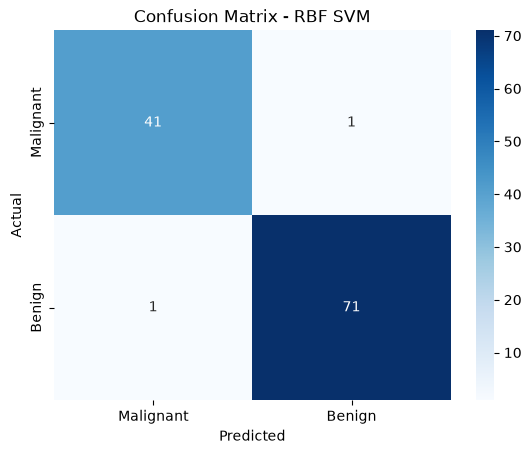

In [30]:
sns.heatmap(
    cm_rbf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Malignant", "Benign"],
    yticklabels=["Malignant", "Benign"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - RBF SVM")
plt.show()

# (d) Classification Report

In [25]:
from sklearn.metrics import classification_report

print("Classification Report - Linear SVM")
print(classification_report(
    y_test,
    y_pred_linear,
    target_names=["Malignant", "Benign"]
))

Classification Report - Linear SVM
              precision    recall  f1-score   support

   Malignant       0.95      0.98      0.96        42
      Benign       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [31]:
print("Classification Report - RBF SVM")
print(classification_report(
    y_test,
    y_pred_rbf,
    target_names=["Malignant", "Benign"]
))

Classification Report - RBF SVM
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

